# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to analyze the Blinkit Grocery Sales dataset, identify business trends, generate actionable insights, and support decision-making through visualizations.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("../data/blinkit_cleaned.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.022911,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.016164,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (8523, 12)


In [7]:
# ==========================
# KPI SUMMARY
# ==========================

total_sales = df['Item_Outlet_Sales'].sum()
average_sales = df['Item_Outlet_Sales'].mean()
average_mrp = df['Item_MRP'].mean()
total_items = len(df)
unique_products = df['Item_Identifier'].nunique()
total_outlets = df['Outlet_Identifier'].nunique()

print(f"Total Sales      : ₹ {total_sales:,.2f}")
print(f"Average Sales    : ₹ {average_sales:,.2f}")
print(f"Average MRP      : ₹ {average_mrp:,.2f}")
print(f"Total Items      : {total_items}")
print(f"Unique Products  : {unique_products}")
print(f"Total Outlets    : {total_outlets}")

Total Sales      : ₹ 18,591,125.41
Average Sales    : ₹ 2,181.29
Average MRP      : ₹ 140.99
Total Items      : 8523
Unique Products  : 1559
Total Outlets    : 10


In [8]:
# Sales by Item Type

sales_by_item = (
    df.groupby("Item_Type")["Item_Outlet_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_item

Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Breads                   5.532372e+05
Hard Drinks              4.577934e+05
Starchy Foods            3.514013e+05
Others                   3.255176e+05
Breakfast                2.322990e+05
Seafood                  1.488682e+05
Name: Item_Outlet_Sales, dtype: float64

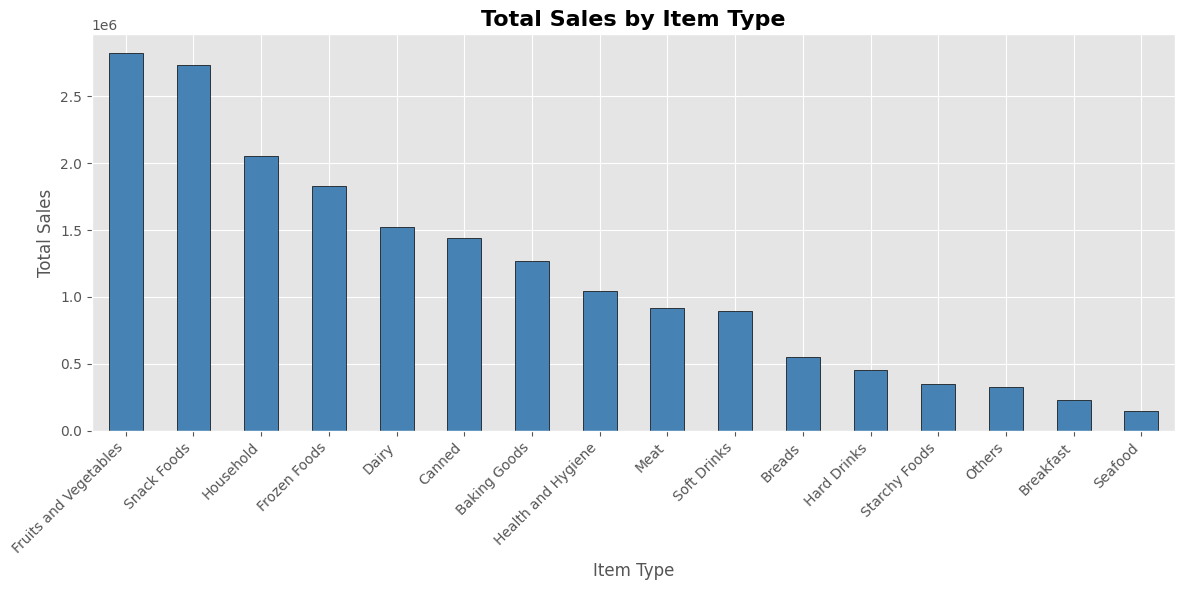

In [9]:
plt.figure(figsize=(12,6))

sales_by_item.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Total Sales by Item Type", fontsize=16, fontweight="bold")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Product Performance Analysis
#Business Question
**Which product categories generate the highest total sales?**

In [10]:
sales_by_fat = (
    df.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_fat

Item_Fat_Content
Low Fat    1.190409e+07
Regular    6.687031e+06
Name: Item_Outlet_Sales, dtype: float64

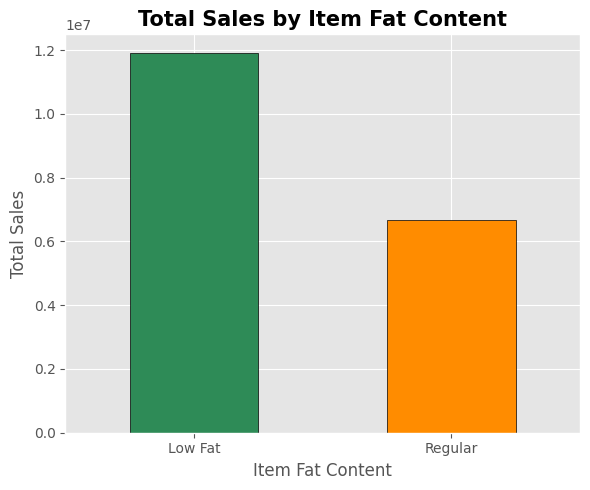

In [11]:
plt.figure(figsize=(6,5))

sales_by_fat.plot(
    kind="bar",
    color=["#2E8B57", "#FF8C00"],
    edgecolor="black"
)

plt.title("Total Sales by Item Fat Content", fontsize=15, fontweight="bold")
plt.xlabel("Item Fat Content")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

# Outlet Performance Analysis
# Business Question
**Which outlet type generates the highest total sales?**

In [12]:
# Sales by Outlet Type

sales_by_outlet = (
    df.groupby("Outlet_Type")["Item_Outlet_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_outlet

Outlet_Type
Supermarket Type1    1.291734e+07
Supermarket Type3    3.453926e+06
Supermarket Type2    1.851823e+06
Grocery Store        3.680343e+05
Name: Item_Outlet_Sales, dtype: float64

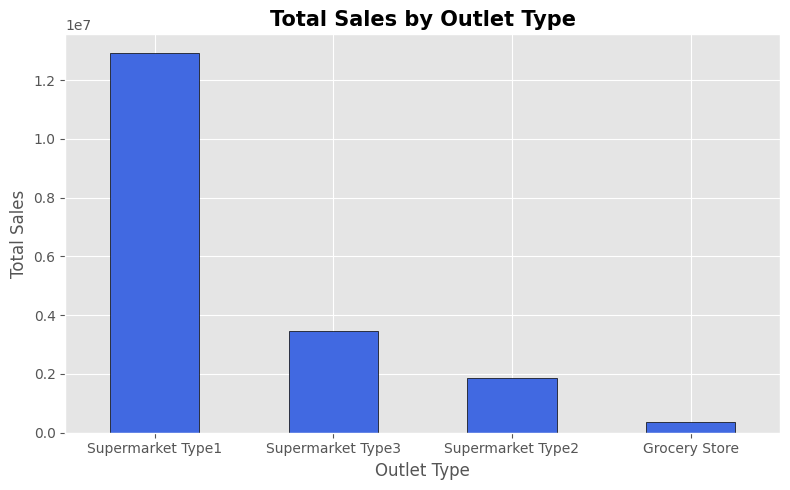

In [13]:
plt.figure(figsize=(8,5))

sales_by_outlet.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Total Sales by Outlet Type", fontsize=15, fontweight="bold")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

- Supermarket Type1 generated the highest total sales among all outlet types.
- Grocery Stores contributed the least revenue.
- Supermarket formats significantly outperform traditional grocery stores in terms of sales.

### Business Recommendation

- Focus expansion strategies on the Supermarket Type1 model.
- Investigate why Grocery Stores generate lower revenue.
- Improve inventory variety and customer engagement in lower-performing outlet formats.

Business Question
Which outlet size contributes the highest total sales?

In [14]:
# Sales by Outlet Size

sales_by_size = (
    df.groupby("Outlet_Size")["Item_Outlet_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_size

Outlet_Size
Small     8.958743e+06
Medium    7.489719e+06
High      2.142664e+06
Name: Item_Outlet_Sales, dtype: float64

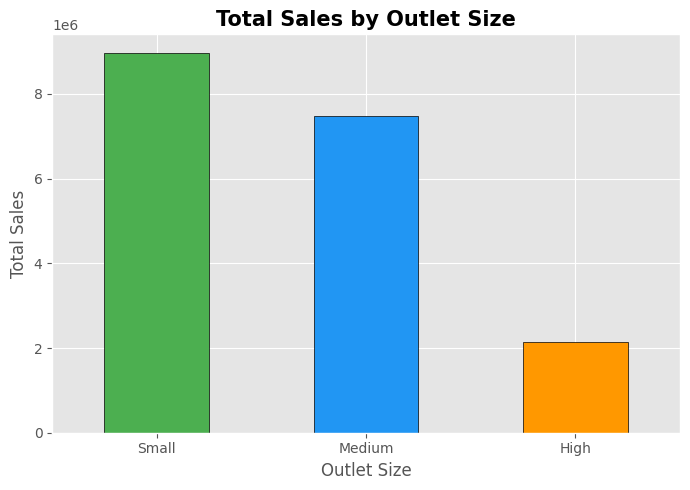

In [15]:
plt.figure(figsize=(7,5))

sales_by_size.plot(
    kind="bar",
    color=["#4CAF50", "#2196F3", "#FF9800"],
    edgecolor="black"
)

plt.title("Total Sales by Outlet Size", fontsize=15, fontweight="bold")
plt.xlabel("Outlet Size")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Outlet Location Analysis
Business Question

**Which outlet location tier generates the highest total sales?**

In [16]:
sales_by_location = (
    df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_location

Outlet_Location_Type
Tier 3    7.636753e+06
Tier 2    6.472314e+06
Tier 1    4.482059e+06
Name: Item_Outlet_Sales, dtype: float64

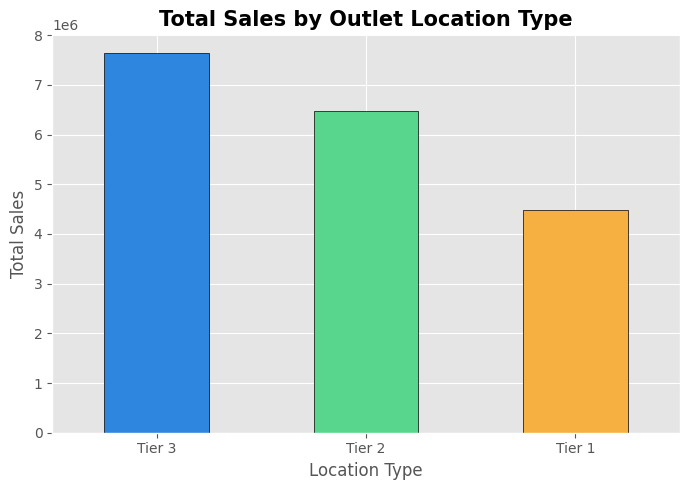

In [17]:
plt.figure(figsize=(7,5))

sales_by_location.plot(
    kind="bar",
    color=["#2E86DE","#58D68D","#F5B041"],
    edgecolor="black"
)

plt.title("Total Sales by Outlet Location Type", fontsize=15, fontweight="bold")
plt.xlabel("Location Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Pricing Analysis Business Question
**How are item prices distributed?**

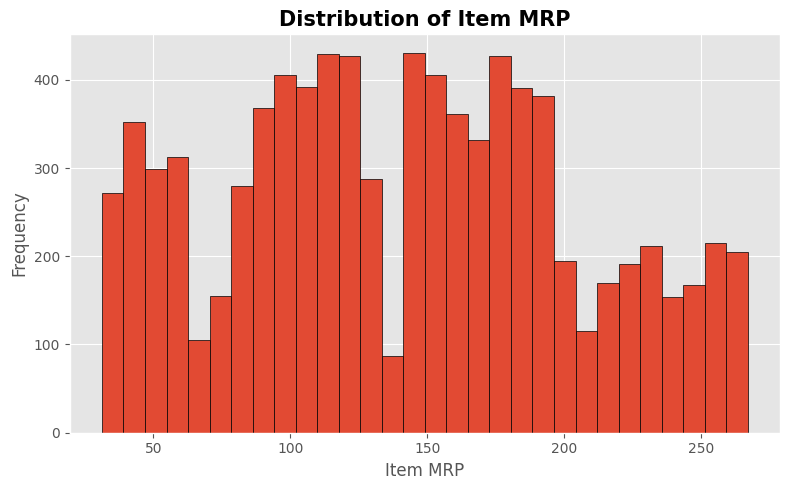

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Item_MRP"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Item MRP", fontsize=15, fontweight="bold")
plt.xlabel("Item MRP")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Sales Distribution Buisness question

**How are sales distributed across all products?**

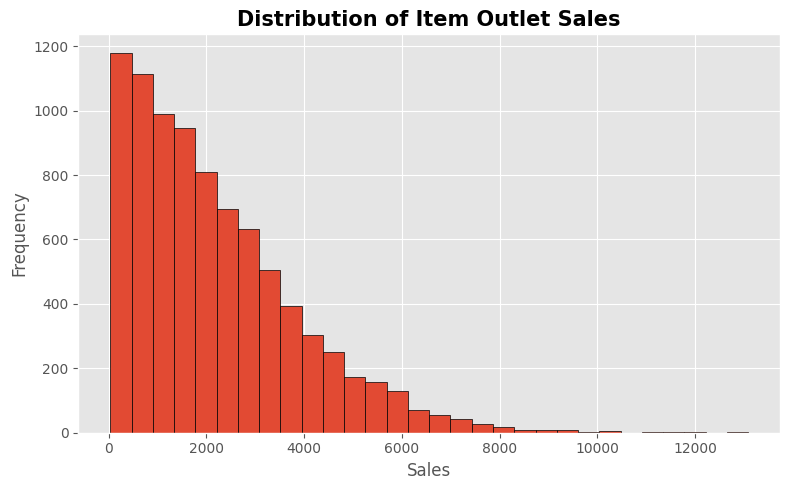

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Item_Outlet_Sales"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Item Outlet Sales", fontsize=15, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Item Visibility Analysis buisnessQuestion
**Does product visibility influence sales?**

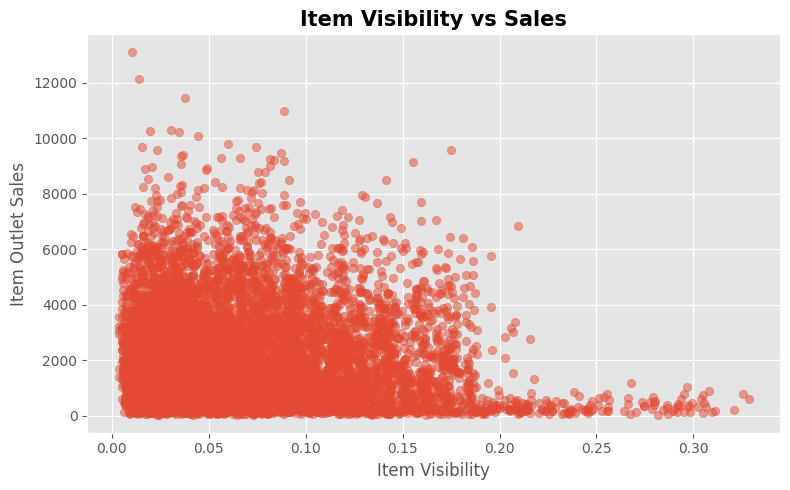

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Item_Visibility"],
    df["Item_Outlet_Sales"],
    alpha=0.5
)

plt.title("Item Visibility vs Sales", fontsize=15, fontweight="bold")
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")

plt.tight_layout()
plt.show()

Pricing vs Sales
Business Question
**Is there a relationship between Item MRP and Sales?**

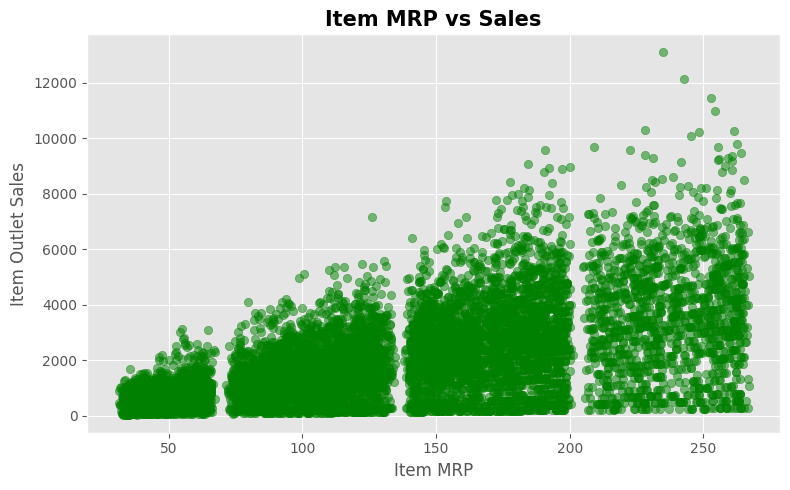

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Item_MRP"],
    df["Item_Outlet_Sales"],
    alpha=0.5,
    color="green"
)

plt.title("Item MRP vs Sales", fontsize=15, fontweight="bold")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.tight_layout()
plt.show()

Correlation Analysis Business Question
**How are numerical variables related to each other?**

In [22]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.021195,0.025986,-0.013383,0.013162
Item_Visibility,-0.021195,1.000000,-0.005951,-0.075238,-0.126026
Item_MRP,0.025986,-0.005951,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.013383,-0.075238,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.013162,-0.126026,0.567574,-0.049135,1.000000


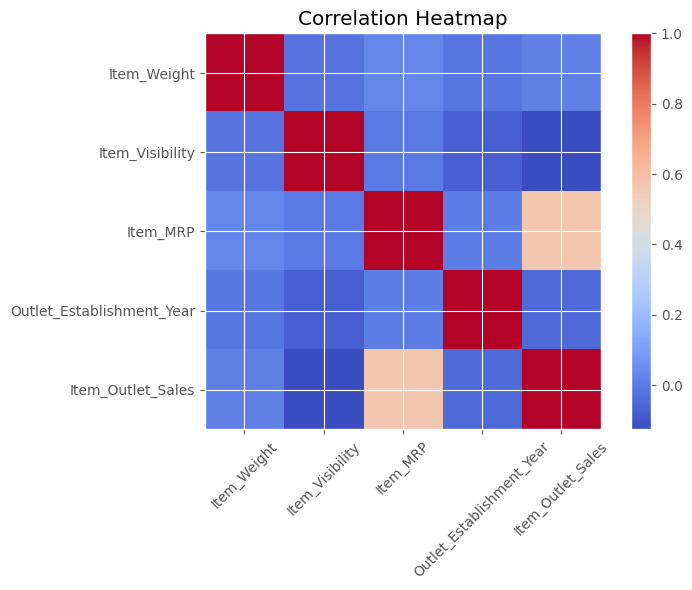

In [23]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

 Outlet Age Analysis : buisness question
**Howdo sales vary across outlet establishment years?**

In [24]:
sales_by_year = (
    df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
      .sum()
      .sort_values()
)

sales_by_year

Outlet_Establishment_Year
1998    1.883402e+05
2009    1.851823e+06
2002    2.036725e+06
1997    2.118395e+06
1987    2.142664e+06
2007    2.167465e+06
1999    2.183970e+06
2004    2.268123e+06
1985    3.633620e+06
Name: Item_Outlet_Sales, dtype: float64

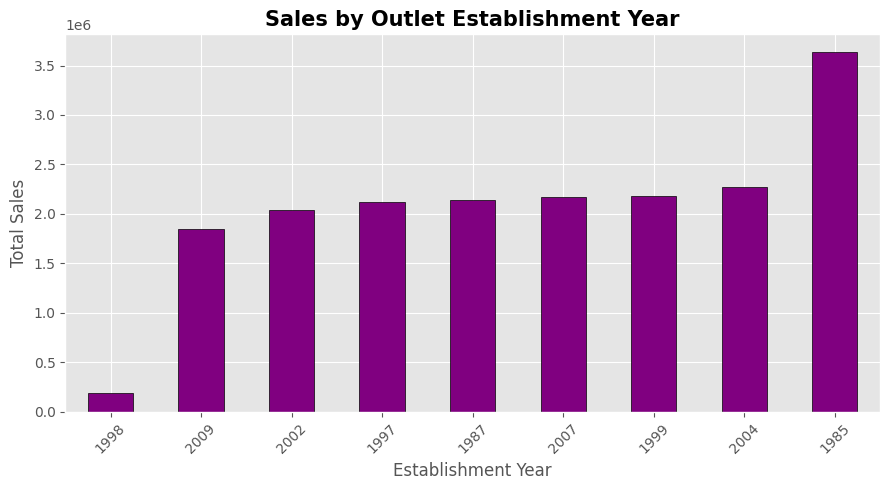

In [25]:
plt.figure(figsize=(9,5))

sales_by_year.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Sales by Outlet Establishment Year", fontsize=15, fontweight="bold")
plt.xlabel("Establishment Year")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Executive Summary

## Key Findings

- Highest Selling Product Category:
- Highest Selling Outlet Type:
- Highest Selling Outlet Size:
- Highest Selling Location Tier:
- Customer Preference:
- Major Revenue Drivers:
- Business Recommendations:

## Conclusion

The exploratory data analysis identified major sales trends, outlet performance, customer preferences, and product performance. These insights will be used to build an interactive Business Intelligence dashboard in Power BI and a web-based analytics application using Streamlit.